In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
rsm.info()

Filename: D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2304, 2313)   int16   
  1  COMPRESSED_IMAGE    1 CompImageHDU     49   (2304, 2313, 118)   int16   


In [4]:
hacore = rsm[1].data[68, :, :]
hawing = rsm[1].data[-10, :, :]
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
headercore = sunpy.map.make_fitswcs_header(hacore, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')

In [5]:
hawing_map = sunpy.map.Map(hawing, headerwing)
hacore_map = sunpy.map.Map(hacore, headercore)

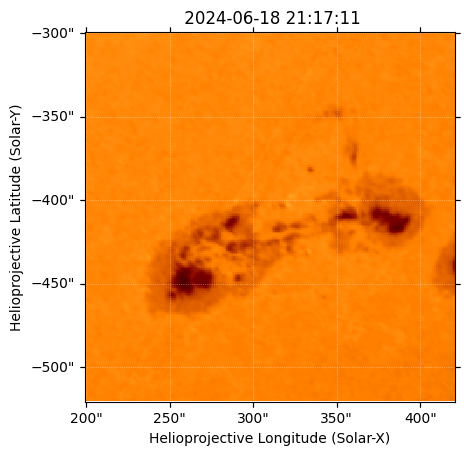

In [13]:
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )
plt.show()

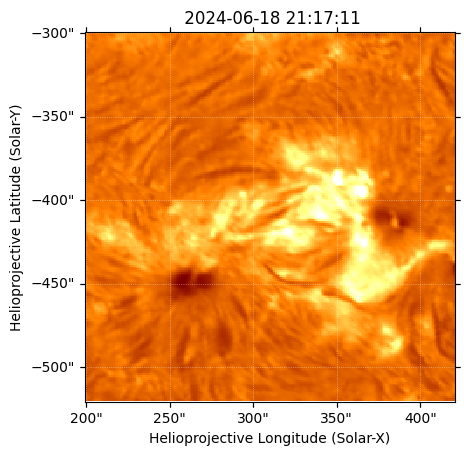

In [14]:
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hacore_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hacore_map.coordinate_frame)
sub_hacore_map=hacore_map.submap(left_bottom,top_right=top_right)
sub_hacore_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hacore_map.data.mean() )
plt.show()

## 画movie

In [29]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\\'
files=sorted(glob.glob(dir+'*.fits'))
for i in range(25,50):
    rsm=fits.open(files[i])
    #hacore = rsm[1].data[68, :, :]
    hawing = rsm[1].data[28, :, :]
    coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = rsm[1].header['DATE_OBS'], observer = 'earth', \
                        frame = frames.Helioprojective)
    headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                        reference_pixel = \
                                        [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                        scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                        telescope = 'CHASE', instrument = 'RSM')
    # headercore = sunpy.map.make_fitswcs_header(hacore, coord_HIS,
    #                                     reference_pixel = \
    #                                     [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
    #                                     scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
    #                                     telescope = 'CHASE', instrument = 'RSM')
    hawing_map = sunpy.map.Map(hawing, headerwing)
    #hacore_map = sunpy.map.Map(hacore, headercore)
    #画线翼的图像
    fig = plt.figure()
    left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
    top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
    sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
    sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )
    #plt.show()
    dir_wing=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hawing\\'
    plt.savefig(dir_wing+files[i][-28:-13]+'.png',dpi=300)
    plt.close()
    # fig = plt.figure()
    # left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hacore_map.coordinate_frame)
    # top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hacore_map.coordinate_frame)
    # sub_hacore_map=hacore_map.submap(left_bottom,top_right=top_right)
    # sub_hacore_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hacore_map.data.mean() )
    # #plt.show()
    # dir_core=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hacore\\'
    # plt.savefig(dir_core+files[i][-28:-13]+'.png',dpi=300)
    # plt.close()

In [30]:
import cv2
import os

def images_to_video(image_folder, output_folder, video_name, fps):
    images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
    images=images[1::2]
    frame = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = frame.shape

    output_path = os.path.join(output_folder, video_name)
    video = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width,height))

    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    cv2.destroyAllWindows()
    video.release()
# images_to_video(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hacore\\'
#                 ,r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\\','CHASE_Ha_core.avi',3)
images_to_video(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hawing\\'
                ,r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\\','CHASE_Ha_wing.avi',3)

In [21]:
a='RSM20240618T194219_0000_HA.fits'
print(a[-28:-13])

20240618T194219


In [4]:
pix_ha = [i for i in range(118)]
wvl_ha = [rsm[1].header['CRVAL3'] + i * rsm[1].header['CDELT3'] for i in range(118)]
f_wvl = interp1d(wvl_ha, pix_ha, 'linear')
wvl_xlabel = [6559.5 + i * 0.5 for i in range(12)]
pix_xlabel = f_wvl(wvl_xlabel)

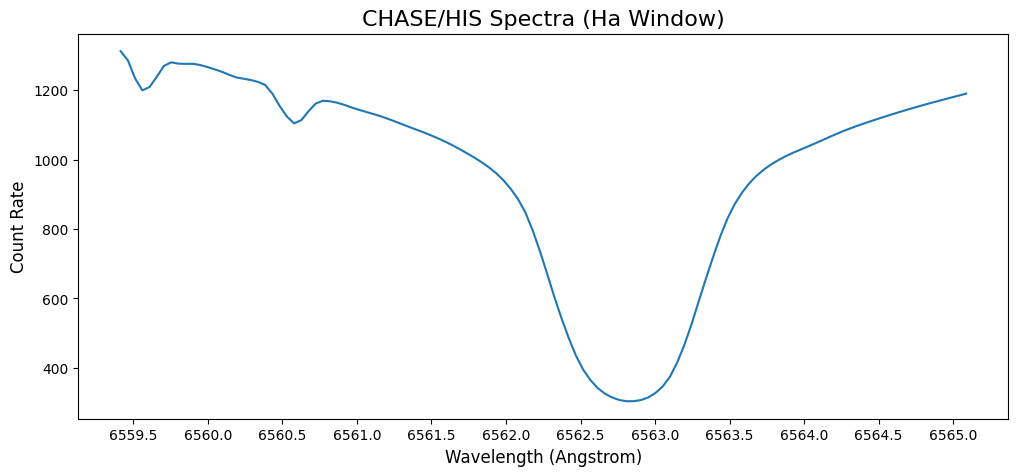

In [6]:
central_spec = rsm[1].data[:, 1000:1200, 1000:1200].mean((1, 2))
plt.figure(figsize = (12, 5))
plt.plot(central_spec)
plt.ylabel('Count Rate', size = 12)
plt.xlabel('Wavelength (Angstrom)', size = 12)
plt.title('CHASE/HIS Spectra (Ha Window)', size = 16)
plt.xticks(pix_xlabel, wvl_xlabel)
plt.show()

In [8]:
def pearson(vector1, vector2):
    # should have len(vector1) == len(vector2)
    n = len(vector1)

    sum1 = sum(vector1)
    sum2 = sum(vector2)

    sum1_pow = sum([pow(v, 2.0) for v in vector1])
    sum2_pow = sum([pow(v, 2.0) for v in vector2])

    p_sum = sum([vector1[i] * vector2[i] for i in range(n)])

    num = p_sum - (sum1 * sum2 / n)
    den = sqrt((sum1_pow - pow(sum1, 2) / n) * (sum2_pow - pow(sum2, 2) / n))
    if den == 0:
        return 0.0
    return num / den

def polyfit_p(x, y, n, draw = 0):
    # return para: a0, a1, a2, ..., an for y = a0 + a1 * x + a2 * x ** 2 + ... + an * x ** n
    pfpara, pfcov = np.polyfit(x, y, n, cov = True)

    if draw != 0:
        plt.subplot(211)
        lx2 = x
        ly2 = []
        for i in range(len(lx2)):
            y2 = 0
            for j in range(len(pfpara)):
                y2 += pfpara[-j - 1] * lx2[i] ** j
            ly2.append(y2)
        plt.plot(x, y, 'ro', lx2, ly2, 'b', linewidth = 2)
        plt.grid()

        plt.subplot(212)
        l0 = []
        lr = []
        for i in range(len(lx2)):
            l0.append(0)
            lr.append(y[i] - ly2[i])
        plt.plot(x, l0, 'black', linewidth = 2)
        plt.scatter(x, lr, color = 'red')
        plt.grid()

    para = list(pfpara)
    para = para[::-1]

    mat_cov = []
    for i in range(len(pfcov)):
        mat_cov.append(pfcov[-i - 1][-i - 1])

    return para, mat_cov

-0.114589693263458 km/s


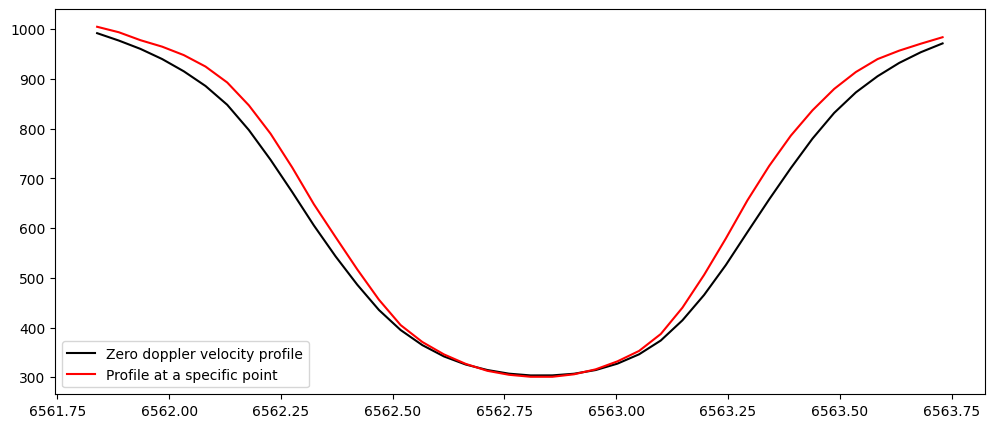

In [9]:
ij_spec = rsm[1].data[50:90, 1000, 1000]

dict_c = {}
for lag in range(-10, 11):
    ha_profilel = central_spec[lag + 50:lag + 90] # move the ha profile, but keep the length
    pr = pearson(ha_profilel, ij_spec)
    dict_c[-lag] = pr

# use cubic fit to get the lag of the largest pearson correlation
lag_max = max(dict_c, key = lambda x:dict_c[x])
l_lag = [lag_max - k for k in range(-2, 3)]

l_pr = [dict_c[k] for k in l_lag]

para_cf, pcov_cf = polyfit_p(l_lag, l_pr, 3)

a0, a1, a2, a3 = para_cf[0], para_cf[1], para_cf[2], para_cf[3] # in format of a0 + a1 * x  + a2 * x ** 2 + a3 * x ** 3
s0, s1, s2, s3 = pcov_cf[0], pcov_cf[1], pcov_cf[2], pcov_cf[3]

dcf01 = (-2 * a2 + sqrt((2 * a2) ** 2 - 12 * a1 * a3)) / (6 * a3)
dcf02 = (-2 * a2 - sqrt((2 * a2) ** 2 - 12 * a1 * a3)) / (6 * a3)

d2cf1 = 6 * a3 * dcf01 + 2 * a2
d2cf2 = 6 * a3 * dcf02 + 2 * a2

covcf1_2 = s1 * (1 / ((2 * a2) ** 2 - 12 * a1 * a3)) + \
s2 * (-1 / (3 * a3) + 2 * a2 / (3 * a3 * sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2 + \
s3 * (a2 / (3 * a3 ** 2) - (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt((2 * a2) ** 2 - 12 * a1 * a3) + \
sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2
covcf2_2 = s1 * (1 / ((2 * a2) ** 2 - 12 * a1 * a3)) + \
s2 * (-1 / (3 * a3) - 2 * a2 / (3 * a3 * sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2 + \
s3 * (a2 / (3 * a3 ** 2) + (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt((2 * a2) ** 2 - 12 * a1 * a3) + \
sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2

if d2cf1 < 0:
    cal_shift_cf = dcf01
    cal_stddev_cf = sqrt(covcf1_2)
else:
    cal_shift_cf = dcf02
    cal_stddev_cf = sqrt(covcf2_2)

print(cal_shift_cf * 1.1068, 'km/s')
plt.figure(figsize = (12, 5))
plt.plot(wvl_ha[50:90], central_spec[50:90], color = 'black', label = 'Zero doppler velocity profile')
plt.plot(wvl_ha[50:90], ij_spec, color = 'red', label = 'Profile at a specific point')
plt.legend()

In [ ]:
def gaussian(x, a, x0, sigma,noise):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))+noise